In [80]:
import torch  
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time
import math

In [81]:

VOCAB_SIZE = 64 
D_MODEL = 48
N_HEADS = 4 
N_LAYERS = 3 
D_FF = 96
MAX_LEN = 2048 

PROMPT = [1, 2, 3, 4, 5]
CORRECTNESS_CHECK_TOKENS = 30
GENERATION_LENGHTS = [10, 20, 40, 80, 160, 320]

REAL_LAYERS = 32
REAL_HEADS = 32
REAL_HEAD_DIM = 128 
REAL_BATCH = 32 
REAL_CONTEXT = 4096



In [82]:
torch.manual_seed(42)

class MaskedMultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = d_model // self.n_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)


    def forward(self, x, past_kv = None, use_cache = False):
        B, T, C = x.shape 
        q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        if past_kv is not None:
            past_k, past_v = past_kv
            k = torch.cat([past_k, k], dim = 2) ## append the k in this step into the cache 
            v = torch.cat([past_v, v], dim = 2) ## append the v in this step into the cache 

        present_kv = (k, v) if use_cache else None

        attention = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        ## the Tk, and the Tq are what make the KV cache effective
        ## Tk = Cached token + New token 
        ## Tq = New token
        Tq, Tk = attention.shape[-2], attention.shape[-1]
        mask = torch.triu(torch.ones(Tq, Tk, dtype = torch.bool, device = x.device), diagonal = Tk - Tq + 1)
        ## this does, Tk x Tq and return False/True. True = not allowed to see and False = allowed to see
        attention = attention.masked_fill(mask, float("-inf"))
        attention = F.softmax(attention, dim = -1)

        out = attention @ v 
        out = out.transpose(1, 2).contiguous().view(B, Tq, C)
        return self.out_proj(out), present_kv


class PositionWiseFNN(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(0.05)
        
    def forward(self, x):
        return self.dropout(self.fc2(F.relu(self.fc1(x))))

class Block(nn.Module):
    def __init__(self, d_model, n_heads, d_ff):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.att = MaskedMultiHeadSelfAttention(d_model, n_heads)
        self.ln2 = nn.LayerNorm(d_model)
        self.fnn = PositionWiseFNN(d_model, d_ff)



    def forward(self, x, past_kv = None, use_cache = False):
        attention_out, present_kv = self.att(self.ln1(x), past_kv, use_cache)
        x = x + attention_out
        x = x + self.fnn(self.ln2(x))
        return x, present_kv


In [83]:
class tinyGPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, max_len):
        super().__init__()
        self.tok_embed = nn.Embedding(vocab_size, d_model)
        self.pos_embed = nn.Embedding(max_len, d_model)
        self.blocks = nn.ModuleList([Block(d_model, n_heads, d_ff) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias = False)

    def forward(self, idx, past_key_values = None, use_cache = False):
        B, T = idx.shape
        offset = past_key_values[0][0].shape[2] if past_key_values is not None else 0
        pos = torch.arange(offset, offset + T, device = idx.device)
        x = self.tok_embed(idx) + self.pos_embed(pos)[None, :, :]

        presents = [] if use_cache else None
        for i, block in enumerate(self.blocks):
            past = past_key_values[i] if past_key_values is not None else None 
            x, present = block(x, past, use_cache)
            if use_cache:
                presents.append(present)

        x = self.ln_f(x)
        logits = self.head(x)
        return logits, presents


model = tinyGPT(VOCAB_SIZE, D_MODEL, N_HEADS, N_LAYERS, D_FF, MAX_LEN).eval()

print(f"TinyGPT: {sum(p.numel() for p in model.parameters()):,} parameters")


TinyGPT: 161,424 parameters


### Generation with no Cache

In [84]:
@torch.no_grad()
def generation_no_cache(model, prompt_ids, n_new_tokens):
    tokens = list(prompt_ids)
    for _ in range(n_new_tokens):
        idx = torch.tensor([tokens], dtype = torch.long) ## convert it from list int into tensor 

        logits, _ = model(idx, use_cache = False)
        next_id = int(torch.argmax(logits[0, -1]))
        tokens.append(next_id)

    return tokens 

    

### Generation with KV Cache

In [85]:
@torch.no_grad()
def generation_with_cache(model, prompt_ids, n_new_tokens):
    tokens = list(prompt_ids)

    idx = torch.tensor([tokens], dtype=torch.long)
    logits, past = model(idx, use_cache=True)
    next_id = int(torch.argmax(logits[0, -1]))
    tokens.append(next_id)

    for _ in range(1, n_new_tokens):
        idx = torch.tensor([[tokens[-1]]], dtype=torch.long)
        logits, past = model(idx, past_key_values=past, use_cache=True)
        next_id = int(torch.argmax(logits[0, -1]))
        tokens.append(next_id)

    return tokens

In [86]:
## check point

no_cache_out = generation_no_cache(model, PROMPT, CORRECTNESS_CHECK_TOKENS)
cache_out = generation_with_cache(model, PROMPT, CORRECTNESS_CHECK_TOKENS)

## since we want it to be matched!
assert no_cache_out == cache_out, "Cached and non-cached generations diverged!"

print("Cached generation exactly matched non-cached generation")
print("No cache:", no_cache_out)
print("With cache:", cache_out)

Cached generation exactly matched non-cached generation
No cache: [1, 2, 3, 4, 5, 40, 63, 23, 13, 8, 29, 62, 3, 30, 46, 14, 63, 12, 39, 14, 63, 63, 57, 13, 53, 15, 39, 37, 28, 51, 26, 63, 31, 18, 51]
With cache: [1, 2, 3, 4, 5, 40, 63, 23, 13, 8, 29, 62, 3, 30, 46, 14, 63, 12, 39, 14, 63, 63, 57, 13, 53, 15, 39, 37, 28, 51, 26, 63, 31, 18, 51]


### Benchmark

In [87]:
def time_generation(fn, model, prompt, n_new):
    start = time.perf_counter()
    fn(model, prompt, n_new)
    return time.perf_counter() - start


no_cache_times, cache_time = [], []

print(f"{"new tokens":>10} | {"no cache (s)":>13} | {"with cache (s)":>15} | speedup")
print("-"*60)

for n_new in GENERATION_LENGHTS:
    t_nc = time_generation(generation_no_cache, model, PROMPT, n_new)
    t_c = time_generation(generation_with_cache, model, PROMPT, n_new)
    no_cache_times.append(t_nc)
    cache_time.append(t_c)

    print(f"{n_new:>10} | {t_nc:<13.4f} | {t_c:>15.4f} | {t_nc / t_c:6.1f}x")

new tokens |  no cache (s) |  with cache (s) | speedup
------------------------------------------------------------
        10 | 0.0059        |          0.0022 |    2.7x
        20 | 0.0083        |          0.0051 |    1.6x
        40 | 0.0199        |          0.0095 |    2.1x
        80 | 0.0435        |          0.0212 |    2.0x
       160 | 0.1311        |          0.0461 |    2.8x
       320 | 0.3586        |          0.0803 |    4.5x


/var/folders/0l/ncq6q9hj0fs3yfnj9xmlzr8m0000gn/T/ipykernel_2952/2103425663.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


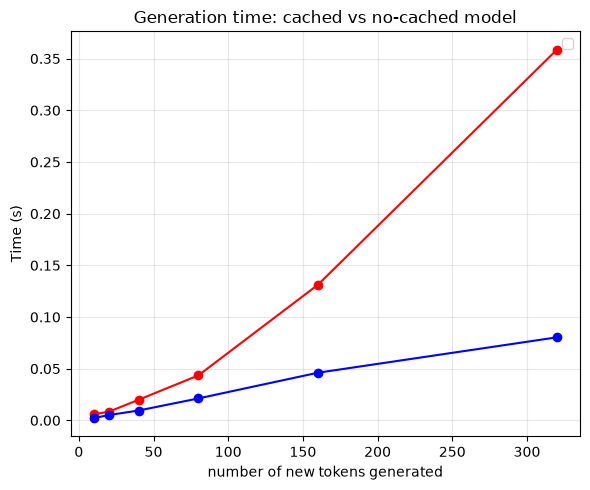

In [96]:
fig, ax = plt.subplots(figsize = (6, 5))

ax.plot(GENERATION_LENGHTS, no_cache_times, "-o", color = "red")
ax.plot(GENERATION_LENGHTS, cache_time, "-o", color = "blue")
ax.set_xlabel("number of new tokens generated")
ax.set_ylabel("Time (s)")
ax.set_title("Generation time: cached vs no-cached model")
ax.legend()
ax.grid(alpha = 0.3)
fig.tight_layout()
#fig.savefig("KV_cache_benchmark.pg", dpi = 150)
plt.show()